In [1]:
# Imports
from astropy import units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord, FK5
from spectral_cube import SpectralCube
from STING import extract_streamline, gradient_descent, outputs
import os
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
# allow jax print statements to show up in the notebook
import jax.numpy as jnp

# Settings
star_position = SkyCoord("3h28m55.569s", "+31d14m37.025s", frame='fk5') #is it possible to get this from the cube?
star_ref = star_position.skyoffset_frame()
distance = 293 #parsecs
v_lsr = 7.5 #km/s
save_folder = "sting_results"

# File
cubefile = 'data/example_streamer_cluster_data.fits'


/Users/laurenmason/.pyenv/versions/.stingenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


STING has been imported. bzzzzzz!


## 1. Prepare 1D streamer emission from cube

The cube should contain only streamer emission. See 'how do I isolate my streamer emission?' (to be written).

Starting reduction
Created coordinate arrays
Got point cloud with 28111 points


Partition boundaries for projected distance metric: [ 1.803  3.453  4.395  5.124  5.798  6.36   6.919  7.579  8.362  9.156
 10.723]


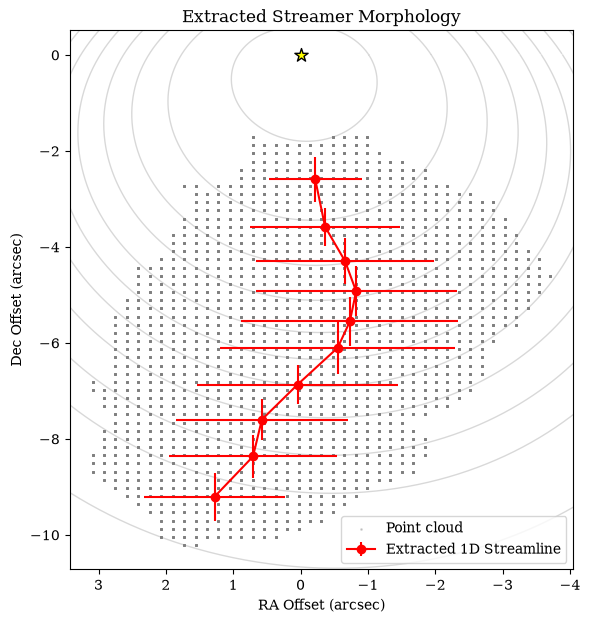

In [2]:
# Set:
n_points = 10 # the number of points we want to reduce the data to
# -----------------------------------------------------------------

# Optional: trim cube to smaller region that just contains the streamer.
# Set any of these to None to not apply that limit.
# ----------------------------------------------------------------
vmin = 6 * u.km/u.s             # e.g. 6 * u.km/u.s
vmax = 8 * u.km/u.s             # e.g. 8 * u.km/u.s  
xmin = -5 * u.arcsec            # e.g. -5 * u.arcsec
xmax = 5 * u.arcsec             # e.g. 5 * u.arcsec 
ymin = -12 * u.arcsec           # e.g. -12 * u.arcsec
ymax = 0.5 * u.arcsec           # e.g. 0.5 * u.arcsec
rms_thresh = 4
# ----------------------------------------------------------------


hdu = fits.open(cubefile)[0]
cube = SpectralCube.read(hdu).with_spectral_unit(u.km/u.s, rest_value=hdu.header['RESTFRQ']*u.Hz)
streamer_cube = extract_streamline.extract_streamer_subcube(cube, vmin=vmin, vmax=vmax, xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax, rms_thresh=rms_thresh)

# Reduce the cube to a 1D streamline
pc_coords, pc_means, pc_stds = extract_streamline.reduce_to_1D(streamer_cube, star_position, n_elements=n_points)
# get metric boundaries for later plotting
partitions = extract_streamline.get_metric_partitions(pc_coords, n_elements=n_points)
metric_boundaries, trace = extract_streamline.sample_metric_boundaries(pc_coords, partitions)

# Give data stuff nice names for later
ra_data, dec_data, v_data = pc_means
ra_sigma, dec_sigma, v_sigma = pc_stds
data = (ra_data, dec_data, v_data)
uncertainties = (ra_sigma, dec_sigma, v_sigma)

# plot the extracted morphology
outputs.plot_morphology(
    ra_data=ra_data,
    dec_data=dec_data,
    ra_sigma=ra_sigma,
    dec_sigma=dec_sigma,
    pc_coords=pc_coords,
    show=True,
    save_folder=None,
    metric_boundaries=metric_boundaries,
    title="Extracted Streamer Morphology",
)


## 2. Initial Guess

First set your input params in the format required (separate params to optimise and params to stay fixed). Use units.

In [3]:
# Parameters to optimize
initial_opt_params = {
    'r0': 1500.0 * u.au,  # au
    'theta0': 40.0 * u.deg,  # degrees
    'phi0': 100.0 * u.deg,  # degrees
    # 'rc': 0.1*1500,  # au
    'omega': 5e-13,  # 1/s
    'v_r0': 0.1 * u.km / u.s, # km/s
    # 'inc': -45.0 * u.deg,  # degrees
    # 'pa': 194.0 * u.deg,  # degrees
    # 'mass': 4.0 * u.Msun,  # solar masses
}

# IRAS2A
fixed_params = {
    'inc': -45.0 * u.deg,  # degrees
    'pa': 194.0 * u.deg,  # degrees
    'mass': 4.0 * u.Msun,  # solar masses
    'rmin': 50.0 * u.au,  # au
    'deltar': 30.0 * u.au,  # au
    'v_lsr': 7.5 * u.km / u.s,  # km/s (systemic velocity)
}

Now we run the forward model for the initial guess, and calculate the loss (i.e. the 'difference' between the model and data streamline)

{'r0': Array(1500., dtype=float64), 'theta0': Array(0.6981317, dtype=float64), 'phi0': Array(1.74532925, dtype=float64), 'omega': Array(5.e-13, dtype=float64), 'v_r0': Array(0.1, dtype=float64)}
{'inc': Array(-0.78539816, dtype=float64), 'pa': Array(3.38593875, dtype=float64), 'mass': Array(4., dtype=float64), 'rmin': Array(50., dtype=float64), 'deltar': Array(30., dtype=float64), 'v_lsr': Array(7.5, dtype=float64)}
ra_model_interp = [-1.77969694 -1.72530043 -1.65194828 -1.56814391 -1.48438951 -1.42655017
 -1.35896178 -1.28335802 -1.19442413 -1.07351681]
ra_model_interp (valid) = [-1.77969694 -1.72530043 -1.65194828 -1.56814391 -1.48438951 -1.42655017
 -1.35896178 -1.28335802 -1.19442413 -1.07351681]
retained 10/10 data points after overlap filtering
Chi2 r: 33.57, Chi2 theta: 289.89, Chi2 v: 13.94, Total: 337.41


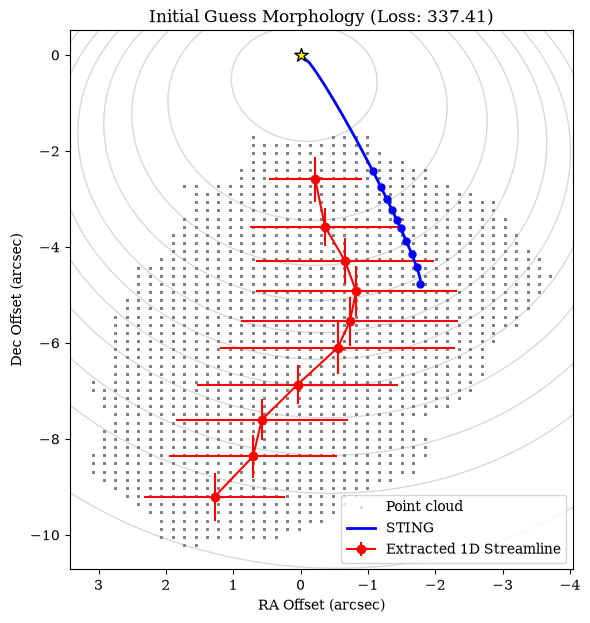

In [4]:
# forward model (same inputs as chi2_loss)
model_params, initial_opt_params, fixed_params = gradient_descent.prepare_model_params(initial_opt_params, fixed_params)
ra_model, dec_model, v_model, valid_mask_model, err = gradient_descent.forward_model(
    model_params, distance
)
err.throw()

# match model to data exactly as chi2_loss does
ra_model_interp, dec_model_interp, v_model_interp, valid, model_keep, _dmetric_model, _ = gradient_descent.checked_match_model_to_data_curve(
    ra_model, dec_model, v_model, valid_mask_model, ra_data, dec_data
)

print(initial_opt_params)
print(fixed_params)
print(f"ra_model_interp = {ra_model_interp}")
print(f"ra_model_interp (valid) = {ra_model_interp[valid]}")
print(f"retained {int(jnp.sum(valid))}/{len(valid)} data points after overlap filtering")

# ---- Manual chi2_loss calculation (same logic as gradient_descent.chi2_loss) ----
# Coerce to float64 and floor sigmas to avoid division by zero
ra_data_f = jnp.asarray(ra_data, dtype=jnp.float64)
dec_data_f = jnp.asarray(dec_data, dtype=jnp.float64)
v_data_f = jnp.asarray(v_data, dtype=jnp.float64)

ra_sigma_f = jnp.asarray(ra_sigma, dtype=jnp.float64)
dec_sigma_f = jnp.asarray(dec_sigma, dtype=jnp.float64)
v_sigma_f = jnp.asarray(v_sigma, dtype=jnp.float64)

eps = jnp.asarray(1e-8, dtype=jnp.float64)
ra_sigma_safe = jnp.maximum(ra_sigma_f, eps)
dec_sigma_safe = jnp.maximum(dec_sigma_f, eps)
v_sigma_safe = jnp.maximum(v_sigma_f, eps)

r_data, theta_data = extract_streamline.cartesian_to_polar(ra_data_f, dec_data_f)
r_model, theta_model = extract_streamline.cartesian_to_polar(ra_model_interp, dec_model_interp)

dtheta = extract_streamline.wrap_to_pi(theta_data - theta_model)

sigma_r = jnp.sqrt(ra_sigma**2 + dec_sigma**2)
r_eps = 1e-8
r_safe = jnp.maximum(jnp.abs(r_data), r_eps)
sigma_theta = jnp.sqrt(((dec_data * dec_sigma)**2 + (ra_data * ra_sigma)**2)) / (r_safe**2)
sigma_theta = jnp.maximum(sigma_theta, r_eps)

# Only compute chi2 on valid/retained data points
chi2_r = jnp.sum((((r_data[valid] - r_model[valid]) / sigma_r[valid]) ** 2))
chi2_theta = jnp.sum(((dtheta[valid] / sigma_theta[valid]) ** 2))
chi2_v = jnp.sum((((v_data_f[valid] - v_model_interp[valid]) / v_sigma_safe[valid]) ** 2))
chi2_total = chi2_r + chi2_theta + chi2_v # + chi2_penalty


print(
    f"Chi2 r: {chi2_r:.2f}, Chi2 theta: {chi2_theta:.2f}, "
    f"Chi2 v: {chi2_v:.2f}, Total: {chi2_total:.2f}"
)

# get metric boundaries
partitions = extract_streamline.get_metric_partitions(pc_coords, n_elements=n_points)
metric_boundaries, trace = extract_streamline.sample_metric_boundaries(pc_coords, partitions)
# do the plot using the morphology plotting function
outputs.plot_morphology(
    ra_model=jnp.asarray(ra_model, dtype=jnp.float64),
    dec_model=jnp.asarray(dec_model, dtype=jnp.float64),
    ra_data=jnp.asarray(ra_data, dtype=jnp.float64),
    dec_data=jnp.asarray(dec_data, dtype=jnp.float64),
    ra_sigma=jnp.asarray(ra_sigma, dtype=jnp.float64),
    dec_sigma=jnp.asarray(dec_sigma, dtype=jnp.float64),
    ra_model_interp=jnp.asarray(ra_model_interp, dtype=jnp.float64),
    dec_model_interp=jnp.asarray(dec_model_interp, dtype=jnp.float64),
    valid=jnp.asarray(valid, dtype=bool),
    pc_coords=pc_coords,
    save_folder=save_folder,
    save_name='initial_guess_morphology',
    show=True,
    metric_boundaries=metric_boundaries,
    title=f"Initial Guess Morphology (Loss: {chi2_total:.2f})",
)


Now go back and adjust your initial guess parameters if necessary (e.g. if the parameter combination led to an error because the centrifugal radius is larger than r0).

The initial guess does not need to be good, so do not spend long on this step.

Once happy with your initial guess, continue.

## 3. Set bounds

Each optimisable parameter needs a set of bounds, with units. These are used to a) normalise the parameters so that they each contribute to a similar level in the optimisation, and b) make sure STING does not go off in completely the wrong direction.

It is recommended to define your omega bounds based on your r0 bounds to keep the centrifugal radius (r_c) shorter than r0.

In [5]:

opt_params = initial_opt_params.copy()

# Define physically reasonable bounds (omega bounds transformed to natural log space)
# These bounds are also used as normalization anchors: x_norm = (x - min) / (max - min).
# Provide bounds for every optimized parameter, apart from rc/omega and v_r0. 
# These bounds will be automatically derived such that we never encounter rc > r0,
# and we never encounter v_r0 < 0 (unphysical).


param_bounds = {
    'r0': (200.0, 10000.0) * u.au,                    # radius between 200-20000 au
    'theta0': (0.0, 180.0) * u.deg,                    # polar angle 0-180 degrees
    'phi0': (0.0, 360.0) * u.deg,                    # azimuthal angle 0-360 degrees
    # 'mass': (3, 10) * u.Msun,                    # mass between 3.0 and 5.0 solar masses
    # 'inc': (-90.0, 90.0) * u.deg,                    # inclination between -90 and 90 degrees
    # 'pa': (0.0, 360.0) * u.deg,                    # position angle between 0 and 360 degrees
}

## 4. Fit streamline

Choose your settings, or leave them as the defaults, and run STING.

Starting optimisation with 1000 epochs...
Loss method: 1
optimising parameters: ['r0', 'theta0', 'phi0', 'v_r0', 'mu']
Fixed parameters: ['inc', 'pa', 'mass', 'rmin', 'deltar', 'v_lsr']
Threshold-based stopping enabled: loss <= 0.05 for 20 consecutive epochs.
Gradient norm stopping enabled (normalised space): ||grad|| < 0.05 for 20 consecutive epochs.
Initial optimisable values:
  r0: 1500 au
  theta0: 40 deg
  phi0: 100 deg
  v_r0: 0.1 km/s
  mu: 0.00532129
Initial loss: 93.0783

 Starting Epoch 50 -------------------------
Epoch 50/1000, Loss: 1.629786, Best Loss: 1.496811, ||grad||: 7.645288e+01

 Starting Epoch 100 -------------------------
Epoch 100/1000, Loss: 1.285505, Best Loss: 1.285505, ||grad||: 2.519334e+01

 Starting Epoch 150 -------------------------
Epoch 150/1000, Loss: 1.237910, Best Loss: 1.229482, ||grad||: 2.000661e+01

 Starting Epoch 200 -------------------------
Epoch 200/1000, Loss: 1.197985, Best Loss: 1.197985, ||grad||: 1.302337e+01

 Starting Epoch 250 ----

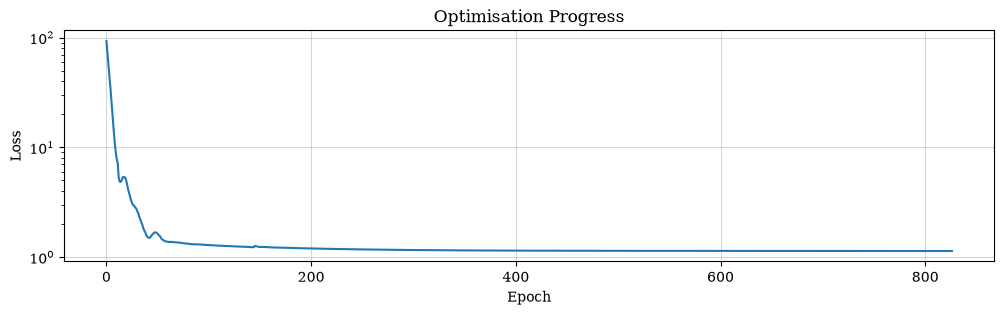

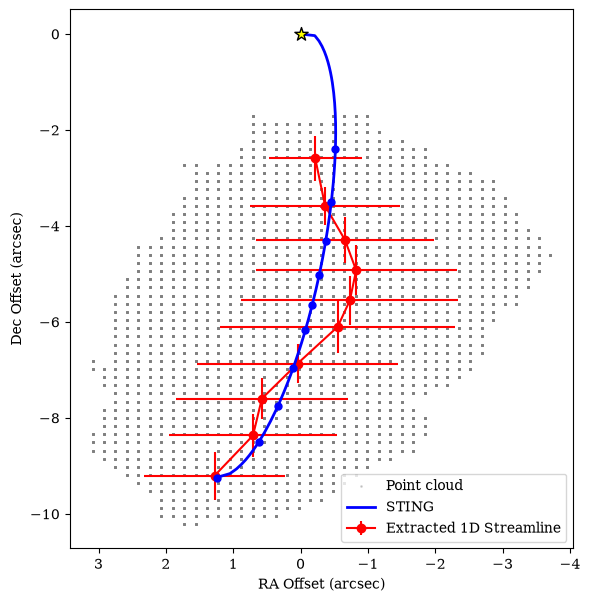

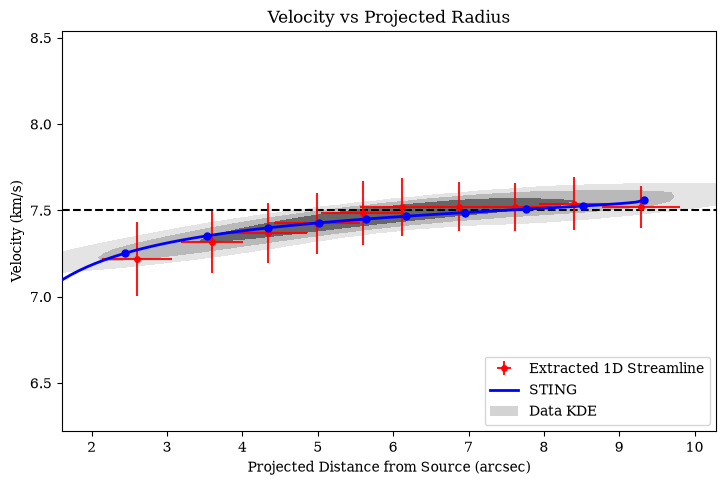

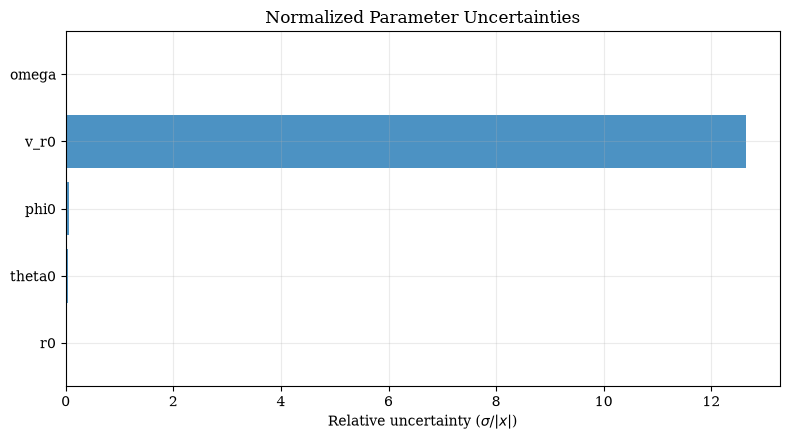

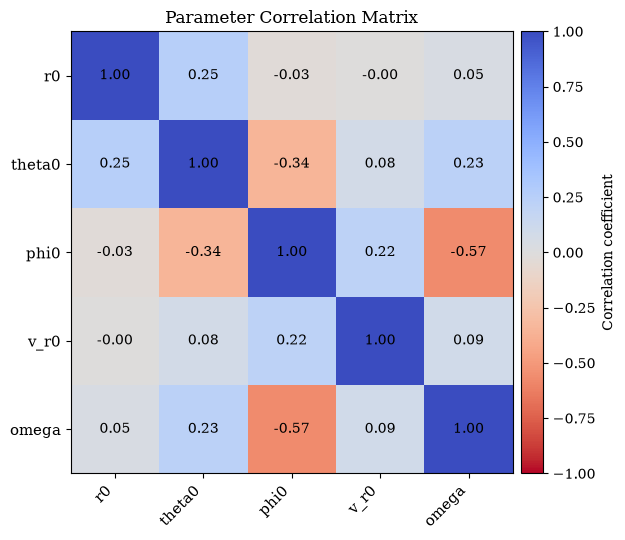

Optimized using loss_method='1'


In [6]:

n_epochs = 1000
info_every = 50
learning_rate = 0.01 # Single learning rate applied to all normalized optimization parameters
loss_method = 1 # options: 0: LOSS_RADECVEL, 1: LOSS_RTHETAVEL
gradient_tol = 1e-2 * len(initial_opt_params) # gradient tolerance scaled by number of parameters

best_opt_params, loss_history, param_errors = gradient_descent.fit_streamline(
    opt_params,
    fixed_params,
    data,
    uncertainties,
    distance,
    learning_rate=learning_rate,
    param_bounds=param_bounds,
    n_epochs=n_epochs,
    info_every=info_every,
    loss_threshold=0.05,
    loss_threshold_epochs=20,
    gradient_tol=gradient_tol,
    gradient_tol_epochs=20,
    early_stopping_patience=210,
    loss_method=loss_method,
    save_folder=save_folder,
    pc_coords=pc_coords,
    v_lsr=v_lsr,
    show_plots=True,
 )

print(f"Optimized using loss_method='{loss_method}'")


## 5. Optional plots

Some other plots which you might wish to make

### Best fit, overlaid with by-eye fit

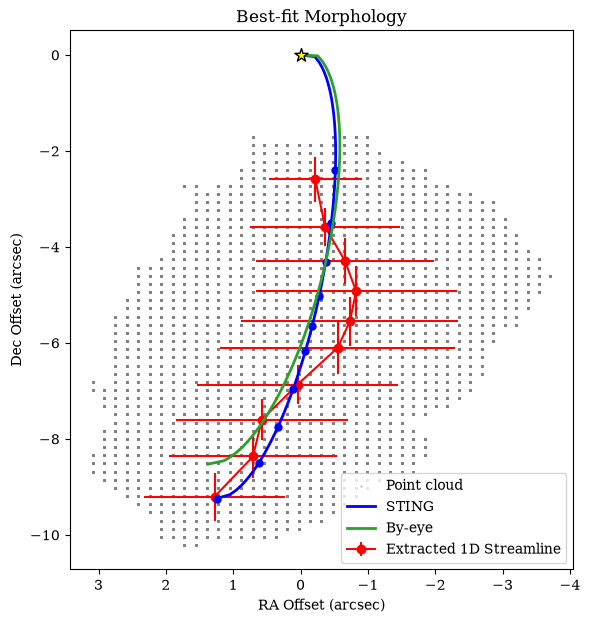

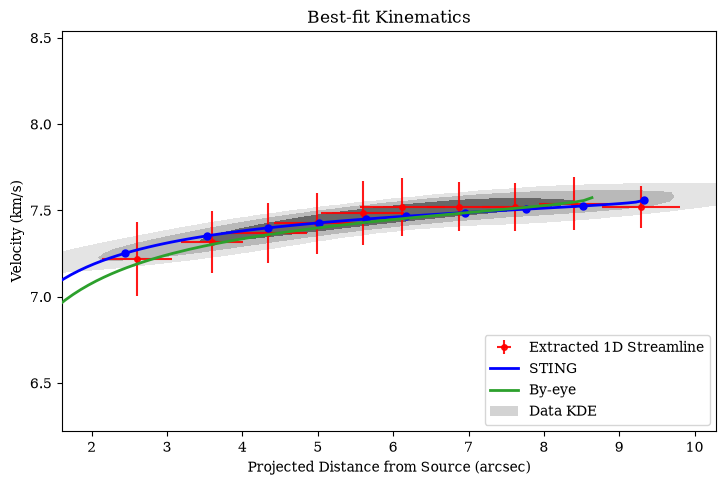

In [7]:
add_by_eye = True
# by eye parameters
by_eye_params = {
    'r0': 2540.0 * u.au,  # au
    'theta0': 54.0 * u.deg,  # degrees
    'phi0': 61.0 * u.deg,  # degrees
    'omega': 7e-13 * (1/u.s),  # 1/s
    'v_r0': 0.001 * u.km / u.s, # km/s
    # 'mass': 4.0 * u.Msun,  # solar masses
    # 'inc': -45.0 * u.deg,  # degrees
    # 'pa': 194.0 * u.deg,  # degrees
}
# convert angles to radians for forward model
if add_by_eye:
    by_eye_full_params, _, _ = gradient_descent.prepare_model_params(by_eye_params, fixed_params)
    ra_by_eye, dec_by_eye, v_by_eye, valid_mask_by_eye, err = gradient_descent.forward_model(by_eye_full_params, distance)
    err.throw()
    by_eye = (ra_by_eye, dec_by_eye, v_by_eye)

# Final model with best-fit parameters
best_opt_full_params, _, _ = gradient_descent.prepare_model_params(best_opt_params, fixed_params)
ra_best, dec_best, v_best, valid_mask_best, err = gradient_descent.forward_model(best_opt_full_params, distance)
err.throw() 
valid_mask_best = valid_mask_best.astype(bool)
# match to data for plotting
ra_best_interp, dec_best_interp, v_best_interp, valid, model_keep, _dmetric_model, _ = gradient_descent.match_model_to_data_curve(
    ra_best, dec_best, v_best, valid_mask_best, ra_data, dec_data
)

# remove NaN values (due to rmin) from model for plotting
not_nan = ~jnp.isnan(ra_best) & ~jnp.isnan(dec_best) & ~jnp.isnan(v_best)
ra_best = ra_best[not_nan]
dec_best = dec_best[not_nan]
v_best = v_best[not_nan]

outputs.plot_morphology(ra_model=jnp.asarray(ra_best), 
                        dec_model=jnp.asarray(dec_best), 
                        ra_data=jnp.asarray(ra_data), 
                        dec_data=jnp.asarray(dec_data),
                        ra_sigma=jnp.asarray(ra_sigma), 
                        dec_sigma=jnp.asarray(dec_sigma),
                        ra_model_interp=jnp.asarray(ra_best_interp),
                        dec_model_interp=jnp.asarray(dec_best_interp),
                        valid=jnp.asarray(valid, dtype=bool),
                        pc_coords=pc_coords, 
                        by_eye=by_eye, 
                        save_folder=save_folder,
                        save_name='best_fit_morphology',
                        title="Best-fit Morphology",
                        show=True)

outputs.plot_vel_radius(ra_model=jnp.asarray(ra_best), 
                        dec_model=jnp.asarray(dec_best),
                        v_model=jnp.asarray(v_best),
                        ra_data=jnp.asarray(ra_data),
                        dec_data=jnp.asarray(dec_data),
                        v_data=jnp.asarray(v_data),
                        ra_sigma=jnp.asarray(ra_sigma),
                        dec_sigma=jnp.asarray(dec_sigma),
                        v_sigma=jnp.asarray(v_sigma),
                        ra_model_interp=jnp.asarray(ra_best_interp),
                        dec_model_interp=jnp.asarray(dec_best_interp),
                        v_model_interp=jnp.asarray(v_best_interp),
                        valid=jnp.asarray(valid, dtype=bool),
                        pc_coords=pc_coords,
                        by_eye=by_eye,
                        save_folder=save_folder,
                        save_name='best_fit_vel_radius',
                        title="Best-fit Kinematics",
                        show=True)

### Streamline spaghetti
i.e. sample covariance matrix for best-fit parameters and plot `n_samples` possible streamlines

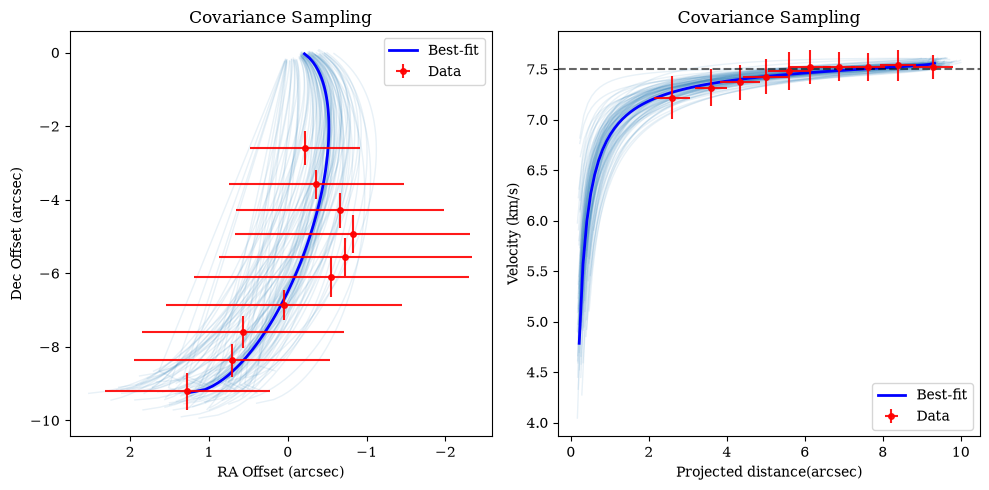

In [8]:
n_samples = 100
outputs.plot_streamline_covariance_samples(best_opt_params,
                                    initial_opt_params,
                                    fixed_params,
                                    data,
                                    uncertainties,
                                    distance,
                                    param_bounds,
                                    loss_method,
                                    gradient_tol,
                                    v_lsr=v_lsr,
                                    n_samples=n_samples,
                                    save_folder=save_folder)

### Parameter evolution

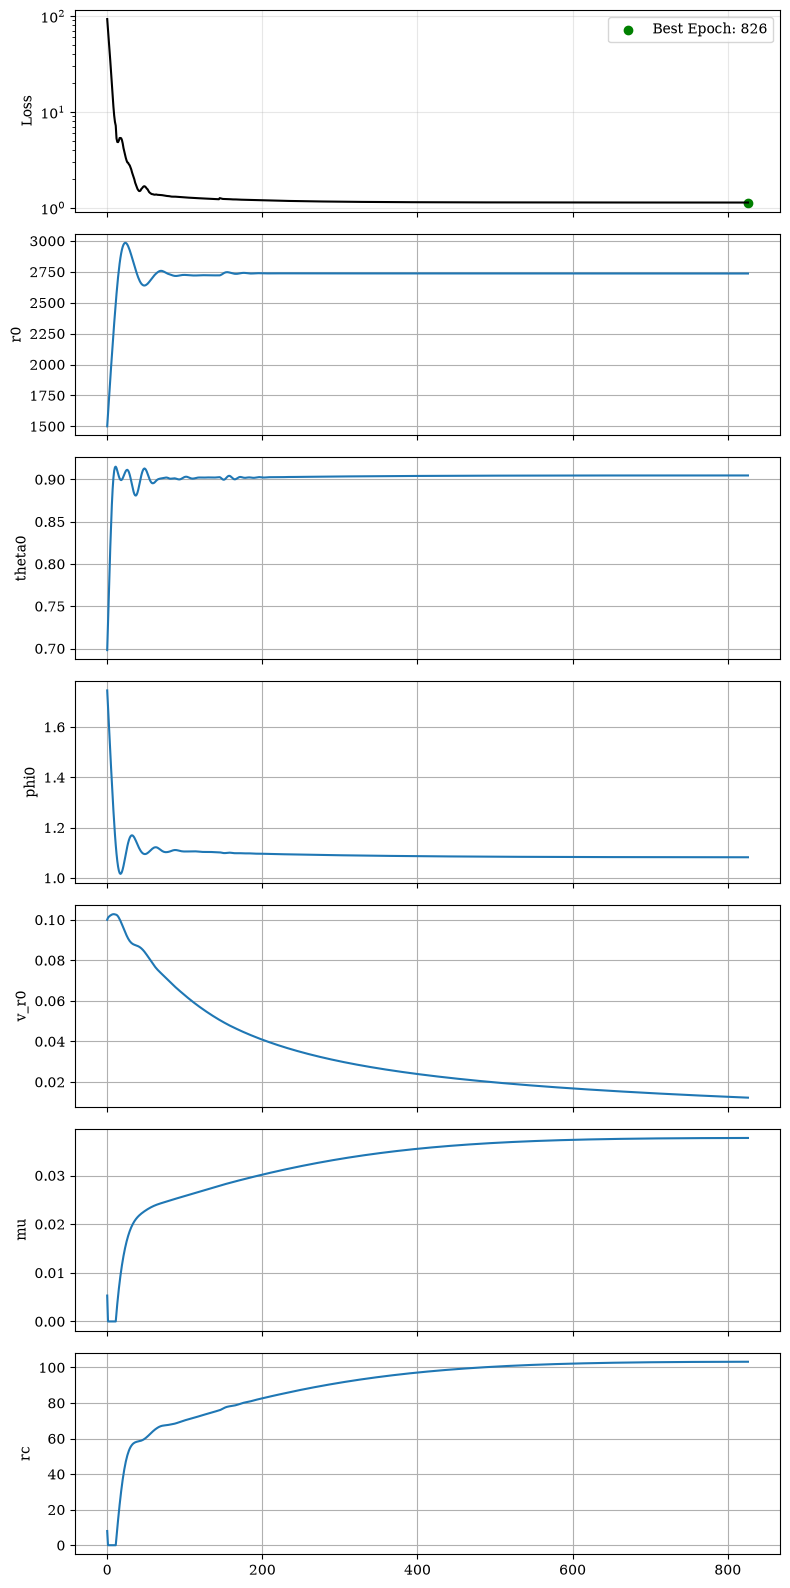

In [9]:
outputs.plot_param_optimisation_history(save_folder=save_folder)

### Plots at every epoch

RA - Dec, RA - Velocity, Dec - Velocity, and Velocity - Projected Radius

Note: time increases ~linearly with number of epochs

Set make_video=True to also string each set of these plots into a video

KeyboardInterrupt: 

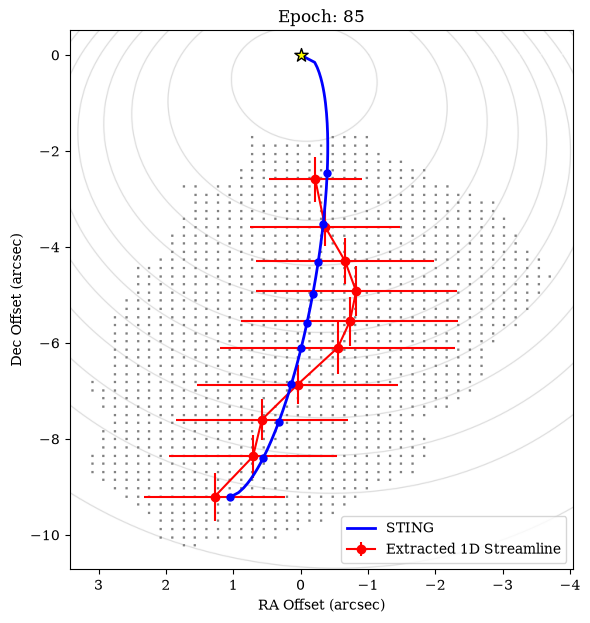

In [10]:
outputs.plot_morphology_by_epoch(
    gradient_descent=gradient_descent,
    fixed_params=fixed_params,
    distance=distance,
    ra_data=jnp.asarray(ra_data),
    dec_data=jnp.asarray(dec_data),
    ra_sigma=jnp.asarray(ra_sigma),
    dec_sigma=jnp.asarray(dec_sigma),
    pc_coords=jnp.asarray(pc_coords),
    n_points=n_points,
    save_folder=save_folder,
    make_video=True
)

In [ ]:
outputs.plot_ra_vel_by_epoch(
    gradient_descent=gradient_descent,
    fixed_params=fixed_params,
    distance=distance,
    ra_data=ra_data,
    dec_data=dec_data,
    v_data=v_data,
    ra_sigma=ra_sigma,
    v_sigma=v_sigma,
    pc_coords=pc_coords,
    save_folder=save_folder,
    make_video=True
)

In [ ]:
outputs.plot_dec_vel_by_epoch(
    gradient_descent=gradient_descent,
    fixed_params=fixed_params,
    distance=distance,
    ra_data=ra_data,
    dec_data=dec_data,
    v_data=v_data,
    dec_sigma=dec_sigma,
    v_sigma=v_sigma,
    pc_coords=pc_coords,
    save_folder=save_folder,
    make_video=True
)

In [ ]:


# now doing plots of velocity vs projected radius by epoch, with a KDE background
outputs.plot_vel_radius_by_epoch(
    gradient_descent=gradient_descent,
    fixed_params=fixed_params,
    distance=distance,
    ra_data=ra_data,
    dec_data=dec_data,
    v_data=v_data,
    pc_coords=pc_coords,
    ra_sigma=ra_sigma,
    dec_sigma=dec_sigma,
    v_sigma=v_sigma,
    velocity_reference=v_lsr,
    save_folder=save_folder,
    make_video=True
)